In [1]:
!pwd

/tmp/truejit/evaluation/bounded-cache


In [3]:
%run /tmp/truejit/evaluation/notebook.shared.py

Plotting setup complete.


In [4]:
publishing = False

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns


def read_input(input):
    return pd.read_csv(
        input,
        names=['strategy', 'global', 'local', 'misses', 'compilations', 'evictions', 'e2e', 'exec', 'waiting', 'gini'],
        sep=';',
        skiprows=1
    )


def adjustments(fig):
    fig.tight_layout()


def write_output(fig, output):
    fig.savefig(output, bbox_inches='tight', pad_inches=0.01, transparent=True, dpi=320, format='pdf')

In [6]:
# input = './in/100-clients.1000ms-delay.5-reps.csv'
# input = './in/ffmpeg.size=10.reps=5.interval=50.csv'
# input = './in/gcc_loops.size=10.reps=5.interval=50.csv'
# input = './in/ffmpeg.size=10.reps=5.interval=10000.csv'
input = './in/ffmpeg.size=10.reps=1.interval=10000.csv'
!cat {input}

compilation_strategy;global;local;misses;compilations;evictions;e2e;exec;waiting;gini
predictive.lstm-50;2500;2500;3913;2460;0;86977351528;81027387833;5949963695;None
jit;2500;2500;9580;2460;0;127732854245;83503665789;44229188455;None
predictive.lstm-50;2500;2000;4091;2460;0;87263245199;80956809759;6306435440;None
jit;2500;2000;9457;2460;0;125448041404;83528047281;41919994122;None
predictive.lstm-50;2500;1500;4436;2460;0;91626784939;81639678468;9987106471;None
jit;2500;1500;9392;2460;0;126726549164;84292886835;42433662329;None
predictive.lstm-50;2500;1000;6371;2460;0;120033808646;84668325400;35365483245;None
jit;2500;1000;9449;2460;0;127693835728;83929593215;43764242513;None
predictive.lstm-50;2500;500;8924;2460;0;184836281728;93573184374;91263097354;None
jit;2500;500;9715;2460;0;155242129983;91117941697;64124188285;None
predictive.lstm-50;2000;2500;16072;11437;9425;100896918260;81336144175;19560774084;None
jit;2000;2500;14153;4669;2669;138939030989;83479086931;55459944057;None
predict

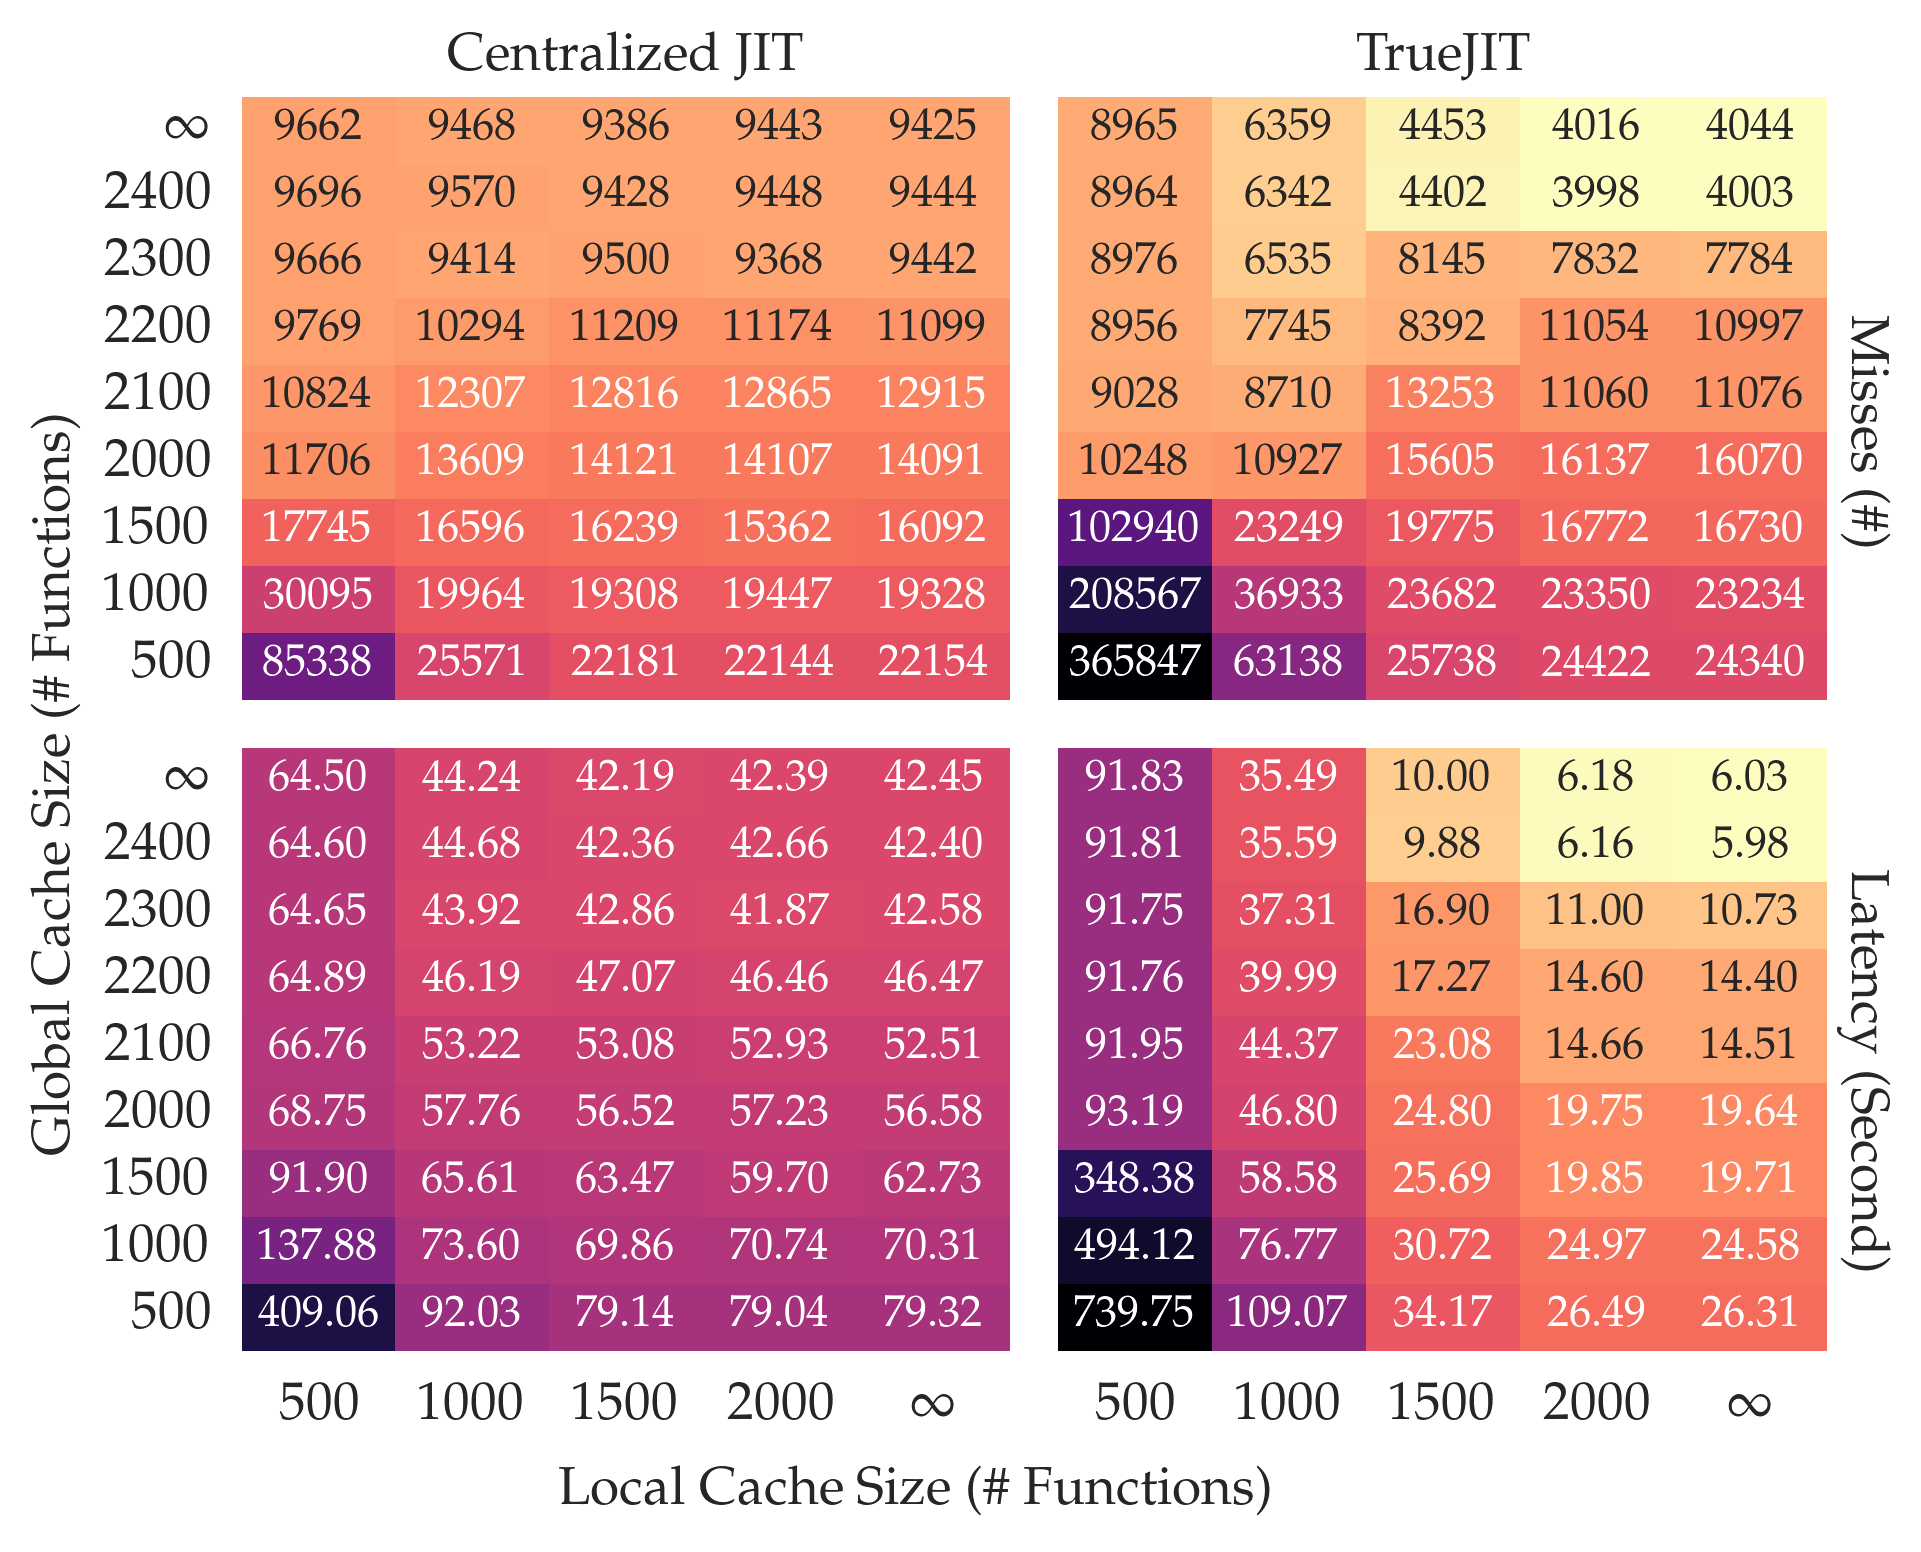

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# Assume these functions are defined elsewhere
# def read_input(path): ...
# def write_output(fig, path): ...
# def adjustments(fig): ...
# publishing = False


def plot_waiting(input_path, output_path):
    fig, axes = plt.subplots(2, 2, figsize=(6, 5), dpi=320, sharey=True, sharex=True)

    df = read_input(input_path)
    df['waiting'] /= 1e9  # Convert nanoseconds to seconds

    centralized_waiting = df[df['strategy'] == 'jit']
    centralized_waiting = centralized_waiting.groupby(['global', 'local']).agg({'waiting': 'mean'}).reset_index()
    centralized_waiting = centralized_waiting.pivot(index='global', columns='local', values='waiting')

    truejit_waiting = df[df['strategy'] == 'predictive.lstm-50']
    truejit_waiting = truejit_waiting.groupby(['global', 'local']).agg({'waiting': 'mean'}).reset_index()
    truejit_waiting = truejit_waiting.pivot(index='global', columns='local', values='waiting')

    vmin = min(centralized_waiting.min().min(), truejit_waiting.min().min())
    vmax = max(centralized_waiting.max().max(), truejit_waiting.max().max())
    norm = LogNorm(vmin=vmin, vmax=vmax)

    # Waiting JIT (bottom left)
    sns.heatmap(centralized_waiting,
                ax=axes[1, 0],
                annot=True,
                fmt=".2f",
                cmap="magma_r",
                norm=norm,
                linewidths=0,
                # linecolor='white',
                cbar=False)

    # Waiting Predictive (bottom right)
    sns.heatmap(truejit_waiting,
                ax=axes[1, 1],
                annot=True,
                fmt=".2f",
                cmap="magma_r",
                norm=norm,
                linewidths=0,
                # linecolor='white',
                cbar=False)

    centralized_misses = df[df['strategy'] == 'jit']
    centralized_misses = centralized_misses.groupby(['global', 'local']).agg({'misses': 'mean'}).reset_index()
    centralized_misses = centralized_misses.pivot(index='global', columns='local', values='misses')
    # make misses int64
    centralized_misses = centralized_misses.astype(int)

    truejit_misses = df[df['strategy'] == 'predictive.lstm-50']
    truejit_misses = truejit_misses.groupby(['global', 'local']).agg({'misses': 'mean'}).reset_index()
    truejit_misses = truejit_misses.pivot(index='global', columns='local', values='misses')
    truejit_misses = truejit_misses.astype(int)

    vmin = min(centralized_misses.min().min(), truejit_misses.min().min())
    vmax = max(centralized_misses.max().max(), truejit_misses.max().max())
    norm = LogNorm(vmin=vmin, vmax=vmax)

    # Waiting JIT (bottom left)
    sns.heatmap(centralized_misses,
                ax=axes[0, 0],
                annot=True,
                fmt="d",
                cmap="magma_r",
                norm=norm,
                linewidths=0,
                # linecolor='white',
                cbar=False)

    # Waiting Predictive (bottom right)
    sns.heatmap(truejit_misses,
                ax=axes[0, 1],
                annot=True,
                fmt="d",
                cmap="magma_r",
                norm=norm,
                linewidths=0,
                # linecolor='white',
                cbar=False)

    axes[0, 0].set_title('Centralized JIT')
    axes[0, 1].set_title('TrueJIT')

    axes[0, 0].set_xlabel('')
    axes[0, 0].set_ylabel('')
    axes[0, 1].set_xlabel('')
    axes[0, 1].set_ylabel('')
    axes[1, 0].set_xlabel('')
    axes[1, 0].set_ylabel('')
    axes[1, 1].set_xlabel('')
    axes[1, 1].set_ylabel('')

    # Set shared labels for the whole figure
    fig.supxlabel(r'Local Cache Size (\# Functions)', fontsize=12, y=.04)
    fig.supylabel(r'Global Cache Size (\# Functions)', fontsize=12, x=.04)

    fig.text(0.98, 0.72, r"Misses (\#)", va='center', ha='left', fontsize=12, rotation=-90)
    fig.text(0.98, 0.32, r"Latency (Second)", va='center', ha='left', fontsize=12, rotation=-90)

    # --- Axis adjustments ---
    axes[1, 0].invert_yaxis()
    axes[1, 0].tick_params(axis='y', rotation=0)
    # Replace x-axis label '2500' with 'unbounded'
    x_labels = [item.get_text() for item in axes[1, 0].get_xticklabels()]
    new_x_labels = [r"$\infty$" if label == '2500' else label for label in x_labels]
    axes[1, 0].set_xticklabels(new_x_labels, fontsize=12)
    axes[1, 1].set_xticklabels(new_x_labels, fontsize=12)

    # Replace shared y-axis label '2500' with 'unbounded'
    y_labels = [item.get_text() for item in axes[1, 0].get_yticklabels()]
    new_y_labels = [r"$\infty$" if label == '2500' else label for label in y_labels]
    axes[0, 0].set_yticklabels(new_y_labels, fontsize=12)
    axes[1, 0].set_yticklabels(new_y_labels, fontsize=12)

    adjustments(fig)
    write_output(fig, output_path)
    fig.show()


# Example usage:
# output = './out/waiting.pdf'
# input_data = input
# plot_waiting(input_data, output)


# Example usage:
output = './out/cache-size-and-waiting.pdf'
input_data = input
plot_waiting(input_data, output)

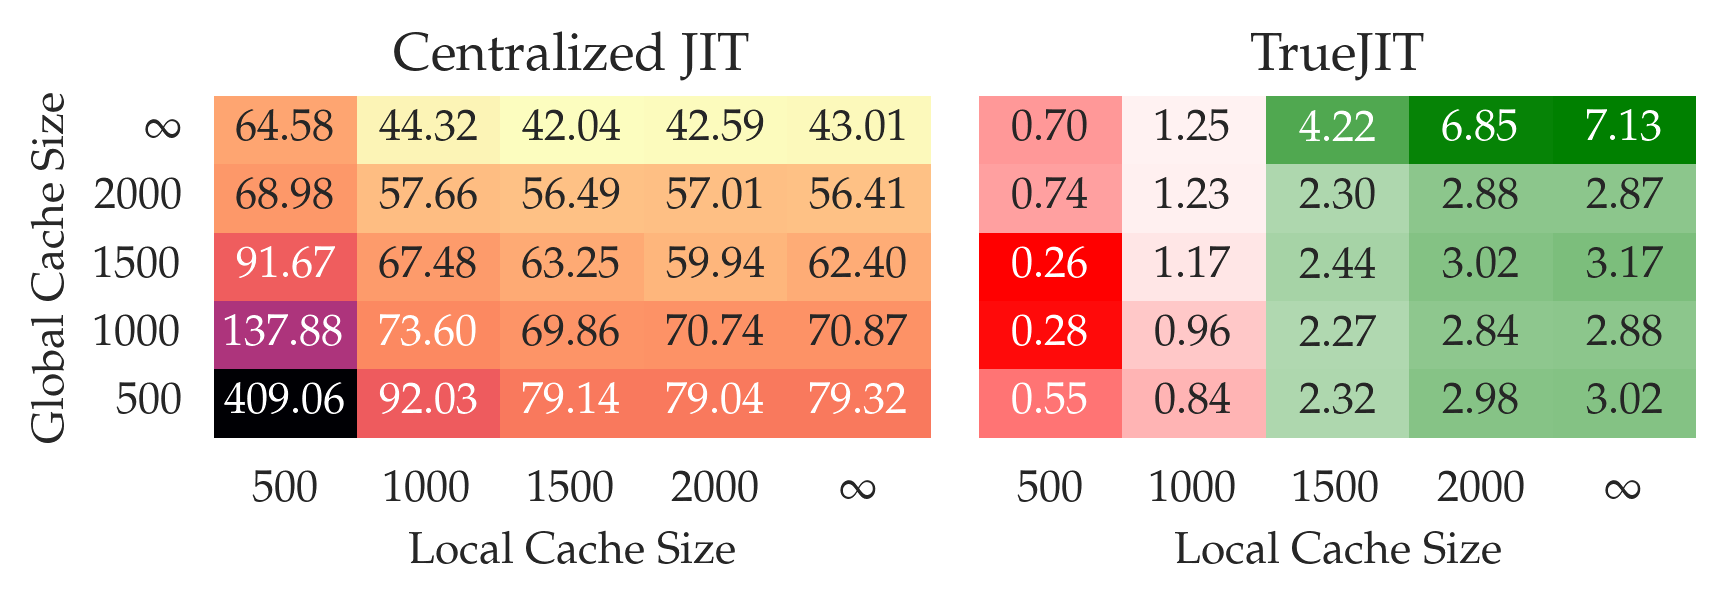

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap


# Assume these functions are defined elsewhere
# def read_input(path): ...
# def write_output(fig, path): ...
# def adjustments(fig): ...
# publishing = False


def plot_waiting(input_path, output_path):
    """
    Plots two side-by-side heatmaps for waiting times of
    'jit' and 'predictive' strategies.
    """
    df = read_input(input_path)
    df['waiting'] /= 1e9  # Convert nanoseconds to seconds

    jit_df = df[df['strategy'] == 'jit']
    jit_pivot = jit_df.groupby(['global', 'local']).agg({'waiting': 'mean'}).reset_index()
    jit_pivot = jit_pivot.pivot(index='global', columns='local', values='waiting')

    predictive_df = df[df['strategy'] == 'predictive.lstm-50']
    predictive_pivot = predictive_df.groupby(['global', 'local']).agg({'waiting': 'mean'}).reset_index()
    predictive_pivot = predictive_pivot.pivot(index='global', columns='local', values='waiting')

    fig, axes = plt.subplots(1, 2, figsize=(5.5, 2), dpi=320, sharey=True)

    vmin = jit_pivot.min().min()
    vmax = jit_pivot.max().max()
    norm = LogNorm(vmin=vmin, vmax=vmax)

    # JIT Heatmap (left)
    sns.heatmap(jit_pivot,
                ax=axes[0],
                annot=True,
                fmt=".2f",
                cmap="magma_r",
                norm=norm,
                linewidths=0,
                # linecolor='white',
                cbar=False)
    axes[0].set_title('Centralized JIT')
    axes[0].set_xlabel('Local Cache Size')
    axes[0].set_ylabel('Global Cache Size')

    predictive_pivot = jit_pivot / predictive_pivot

    # Predictive Heatmap (right)
    sns.heatmap(predictive_pivot,
                ax=axes[1],
                annot=True,
                fmt=".2f",
                cmap=LinearSegmentedColormap.from_list('rg', ["r", "w", "g"], N=256),
                norm=LogNorm(),
                linewidths=0,
                # linecolor='white',
                cbar=False)
    axes[1].set_title('TrueJIT')
    axes[1].set_xlabel('Local Cache Size')
    axes[1].set_ylabel('')

    # --- Axis adjustments ---
    axes[0].invert_yaxis()
    for ax in axes:
        ax.tick_params(axis='y', rotation=0)

        # Replace x-axis label '2500' with 'unbounded'
        x_labels = [item.get_text() for item in ax.get_xticklabels()]
        new_x_labels = [r"$\infty$" if label == '2500' else label for label in x_labels]
        ax.set_xticklabels(new_x_labels)

    # Replace shared y-axis label '2500' with 'unbounded'
    y_labels = [item.get_text() for item in axes[0].get_yticklabels()]
    new_y_labels = [r"$\infty$" if label == '2500' else label for label in y_labels]
    axes[0].set_yticklabels(new_y_labels)

    adjustments(fig)
    write_output(fig, output_path)
    fig.show()


# Example usage:
# output = './out/waiting.pdf'
# input_data = input
# plot_waiting(input_data, output)


# Example usage:
output = './out/waiting.pdf'
input_data = input
plot_waiting(input_data, output)

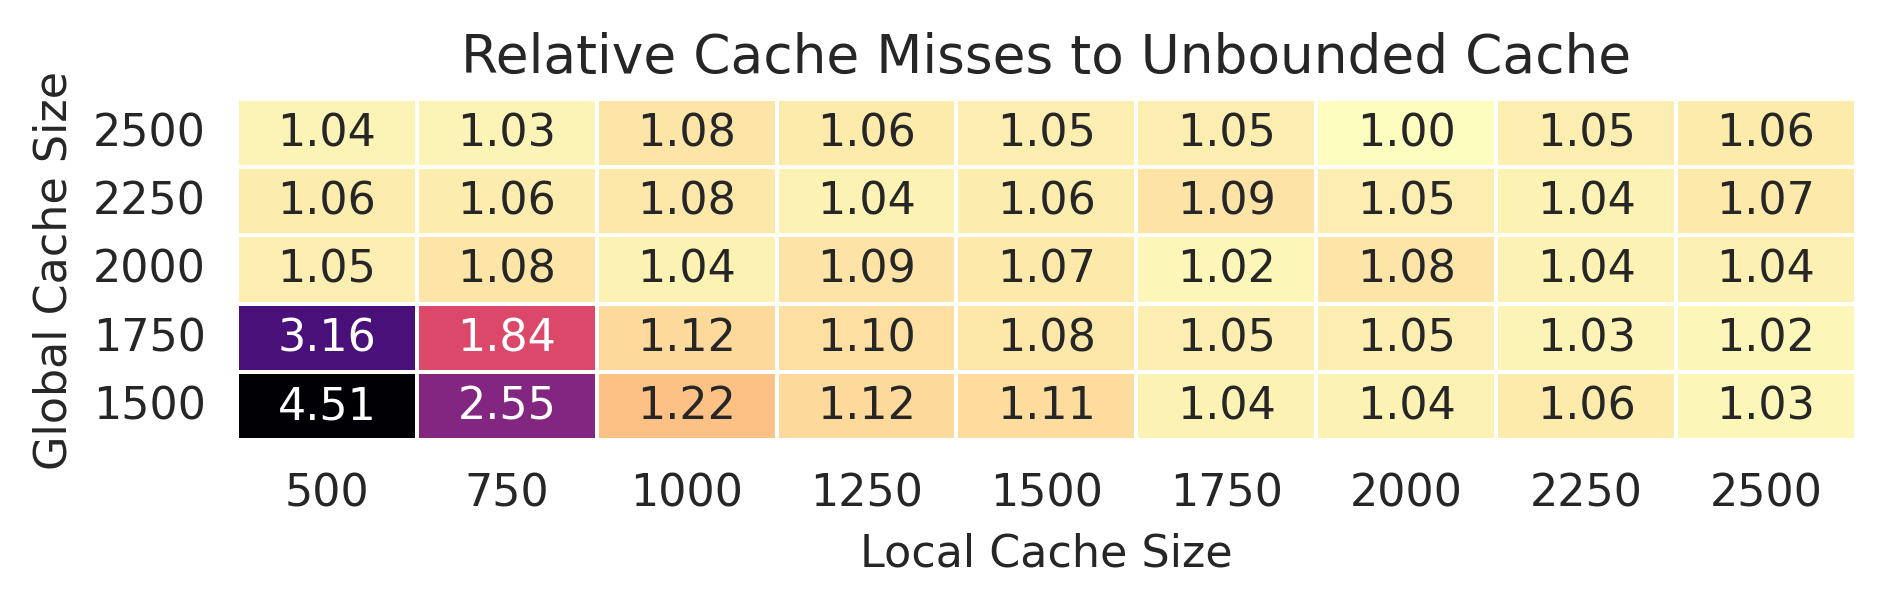

In [7]:
def plot_misses(input, output):
    df = read_input(input)

    df = df.groupby(['global', 'local']).agg({'misses': 'mean'}).reset_index()
    df['misses'] /= df['misses'].min()  # relative to unbounded cache
    df = df.pivot(index='global', columns='local', values='misses')

    fig, ax = plt.subplots(figsize=(6, 2), dpi=320)
    sns.heatmap(df,
                annot=True,
                fmt=".2f",
                cmap="magma_r",
                norm=LogNorm(),
                linewidths=0.5, linecolor='white',
                cbar=False)

    # x-axis
    ax.set_xlabel('Local Cache Size')

    # y-axis
    ax.set_ylabel('Global Cache Size')
    ax.invert_yaxis()
    ax.tick_params(axis='y', rotation=0)

    # title
    if not publishing:
        plt.title('Relative Cache Misses to Unbounded Cache')

    adjustments(fig)

    write_output(fig, output)

    fig.show()


output = '/tmp/misses.pdf'
plot_misses(input, output)

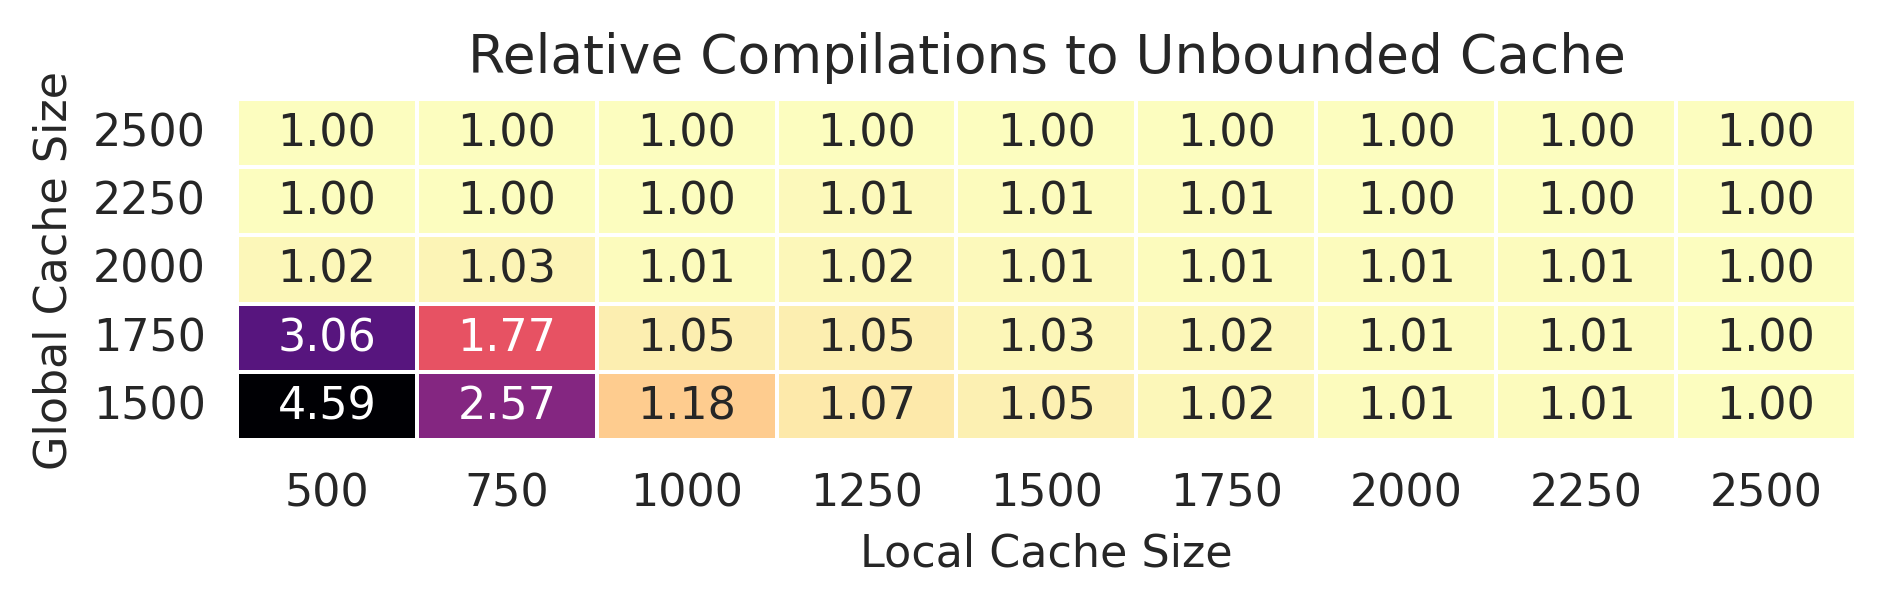

In [8]:
def plot_compilations(input, output):
    df = read_input(input)

    df = df.groupby(['global', 'local']).agg({'compilations': 'mean'}).reset_index()
    df['compilations'] /= df['compilations'].min()
    df = df.pivot(index='global', columns='local', values='compilations')

    fig, ax = plt.subplots(figsize=(6, 2), dpi=320)
    sns.heatmap(df,
                annot=True,
                fmt=".2f",
                cmap="magma_r",
                norm=LogNorm(),
                linewidths=0.5, linecolor='white',
                cbar=False)

    # x-axis
    ax.set_xlabel('Local Cache Size')

    # y-axis
    ax.set_ylabel('Global Cache Size')
    ax.invert_yaxis()
    ax.tick_params(axis='y', rotation=0)

    # title
    if not publishing:
        plt.title('Relative Compilations to Unbounded Cache')

    adjustments(fig)

    write_output(fig, output)

    fig.show()


output = '/tmp/compilations.pdf'
plot_compilations(input, output)

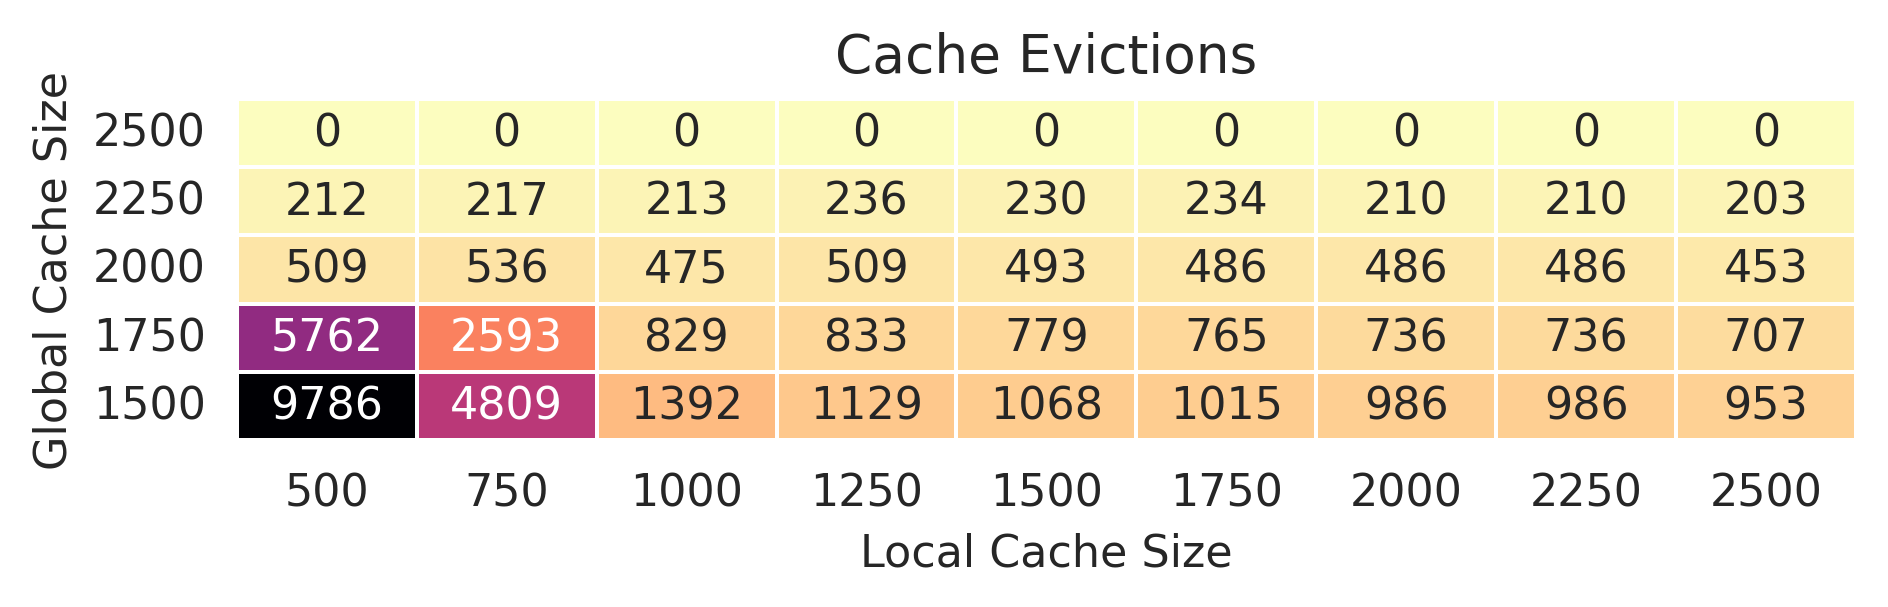

In [9]:
def plot_evictions(input, output):
    df = read_input(input)

    df = df.groupby(['global', 'local']).agg({'evictions': 'mean'}).reset_index()
    df['evictions'] = df['evictions'].astype(int)
    df = df.pivot(index='global', columns='local', values='evictions')

    fig, ax = plt.subplots(figsize=(6, 2), dpi=320)
    sns.heatmap(df,
                annot=True,
                fmt="d",
                cmap="magma_r",
                norm=None,
                linewidths=0.5, linecolor='white',
                cbar=False)

    # x-axis
    ax.set_xlabel('Local Cache Size')

    # y-axis
    ax.set_ylabel('Global Cache Size')
    ax.invert_yaxis()
    ax.tick_params(axis='y', rotation=0)

    # title
    if not publishing:
        plt.title('Cache Evictions')

    adjustments(fig)

    write_output(fig, output)

    fig.show()


output = '/tmp/evictions.pdf'
plot_evictions(input, output)

In [ ]:
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable

# 1. Read the user-provided data into a pandas DataFrame
csv_data = """compilation_strategy;global;local;misses;compilations;evictions;e2e;exec;waiting;gini
predictive.lstm-50;None;None;14607;2460;0;91278002434;57783016057;33494986377;None
jit;None;None;189725;2460;0;138230429420;58149701541;80080727878;None
predictive.lstm-50;None;2500;14430;2460;0;106538399852;74057718023;32480681828;None
jit;None;2500;182297;2460;0;153665393147;74898894311;78766498836;None
predictive.lstm-50;None;2250;14742;2460;0;109592809909;74892491429;34700318480;None
jit;None;2250;189685;2460;0;155406051966;74846711263;80559340702;None
predictive.lstm-50;None;2000;14545;2460;0;107486819100;74180839378;33305979722;None
jit;None;2000;194526;2460;0;156089833945;74855906550;81233927394;None
predictive.lstm-50;None;1750;18417;2460;0;117008702799;74396318205;42612384593;None
jit;None;1750;191877;2460;0;157943404757;74588595498;83354809259;None
predictive.lstm-50;None;1500;19091;2460;0;119792181153;74685057792;45107123361;None
jit;None;1500;188949;2460;0;153307120421;74631700429;78675419991;None
predictive.lstm-50;None;1250;25406;2460;0;129799790945;75010069003;54789721942;None
jit;None;1250;191600;2460;0;155927629961;74723312189;81204317771;None
predictive.lstm-50;None;1000;41249;2460;0;155868593114;75485832616;80382760498;None
jit;None;1000;196195;2460;0;157496090571;75247030124;82249060446;None
predictive.lstm-50;None;750;44177;2460;0;200736761630;77780091171;122956670459;None
jit;None;750;185424;2460;0;161855543446;76331151483;85524391963;None
predictive.lstm-50;None;500;55919;2460;0;328109706187;81019152896;247090553290;None
jit;None;500;177482;2460;0;167467652938;77532667193;89934985745;None
predictive.lstm-50;2500;None;14458;2460;0;90613297848;57996284489;32617013358;None
jit;2500;None;190192;2460;0;137403060652;58073017912;79330042739;None
predictive.lstm-50;2500;2500;14819;2460;0;107243427799;74108171083;33135256715;None
jit;2500;2500;195530;2460;0;157283650456;75368107583;81915542873;None
predictive.lstm-50;2500;2250;14629;2460;0;109093857201;74628262215;34465594986;None
jit;2500;2250;187420;2460;0;154376113457;74989175197;79386938259;None
predictive.lstm-50;2500;2000;14810;2460;0;107270488405;74128524307;33141964097;None
jit;2500;2000;195313;2460;0;158097474874;75166873758;82930601115;None
predictive.lstm-50;2500;1750;17915;2460;0;118800451249;74725953863;44074497386;None
jit;2500;1750;195887;2460;0;158857245177;75109816609;83747428567;None
predictive.lstm-50;2500;1500;19173;2460;0;119482079328;74696956879;44785122448;None
jit;2500;1500;190852;2460;0;154113587028;74739735111;79373851916;None
predictive.lstm-50;2500;1250;27355;2460;0;132634426751;75018133614;57616293136;None
jit;2500;1250;192370;2460;0;156104628868;75168142831;80936486036;None
predictive.lstm-50;2500;1000;41782;2460;0;156979595229;76250592247;80729002981;None
jit;2500;1000;187272;2460;0;156452239780;75768525913;80683713867;None
predictive.lstm-50;2500;750;46046;2460;0;206600681000;78181401238;128419279762;None
jit;2500;750;191945;2460;0;161570853394;76333166954;85237686439;None
predictive.lstm-50;2500;500;55612;2460;0;305942650276;81171933542;224770716734;None
jit;2500;500;182498;2460;0;168971220084;77656166799;91315053284;None
predictive.lstm-50;2250;None;14617;2460;196;90020731840;57648695283;32372036557;None
jit;2250;None;192740;2460;210;137395753600;58190581515;79205172084;None
predictive.lstm-50;2250;2500;14519;2460;208;106451381706;73987129623;32464252083;None
jit;2250;2500;190392;2460;210;156586740077;74720910813;81865829263;None
predictive.lstm-50;2250;2250;14418;2460;208;107431057095;73926159317;33504897777;None
jit;2250;2250;193465;2460;210;157603314617;75722756294;81880558322;None
predictive.lstm-50;2250;2000;14880;2460;210;108528711279;74263993322;34264717957;None
jit;2250;2000;191961;2460;210;158120876883;75536733906;82584142976;None
predictive.lstm-50;2250;1750;18337;2510;260;116793310718;74250772305;42542538412;None
jit;2250;1750;187612;2460;210;156325942546;75135781423;81190161123;None
predictive.lstm-50;2250;1500;18952;2501;251;120127736987;75180751002;44946985985;None
jit;2250;1500;189758;2460;210;156149535163;74677705000;81471830163;None
predictive.lstm-50;2250;1250;27291;2526;259;134319636145;74997540203;59322095942;None
jit;2250;1250;188326;2461;211;154803575296;74767253155;80036322141;None
predictive.lstm-50;2250;1000;41820;2460;210;155656321230;75890417780;79765903449;None
jit;2250;1000;184174;2466;216;155422429425;75017610037;80404819388;None
predictive.lstm-50;2250;750;44072;2460;210;204946806942;78063250002;126883556940;None
jit;2250;750;177895;2465;215;157214448305;75813986347;81400461957;None
predictive.lstm-50;2250;500;55425;2460;210;323676812355;81631784363;242045027992;None
jit;2250;500;183838;2464;214;168263340951;77571063738;90692277212;None
predictive.lstm-50;2000;None;14632;2460;457;90479535962;57959840378;32519695583;None
jit;2000;None;199481;2460;460;138508683023;58112834229;80395848793;None
predictive.lstm-50;2000;2500;14776;2460;459;107470856570;74038315865;33432540705;None
jit;2000;2500;197739;2460;460;154203776880;74710352075;79493424804;None
predictive.lstm-50;2000;2250;14647;2511;511;107517443505;74010892074;33506551431;None
jit;2000;2250;199379;2461;461;154799832324;74816775608;79983056715;None
predictive.lstm-50;2000;2000;14723;2511;511;106936912782;73976624454;32960288328;None
jit;2000;2000;201288;2461;461;159211013636;75225145130;83985868506;None
predictive.lstm-50;2000;1750;18601;2511;511;117129619512;74272605166;42857014345;None
jit;2000;1750;196293;2461;461;153503082922;74641928881;78861154040;None
predictive.lstm-50;2000;1500;19839;2522;522;118645037017;74694257374;43950779643;None
jit;2000;1500;205825;2465;465;155665733949;75127294998;80538438950;None
predictive.lstm-50;2000;1250;28781;2572;572;136733795491;75228194713;61505600778;None
jit;2000;1250;199971;2468;468;154019930318;74671813915;79348116403;None
predictive.lstm-50;2000;1000;43304;2487;487;156499951740;75624301127;80875650613;None
jit;2000;1000;201800;2472;472;155229595291;74632946619;80596648671;None
predictive.lstm-50;2000;750;45987;2636;630;201334066918;77661829424;123672237493;None
jit;2000;750;182949;2480;480;159434689824;76137405682;83297284142;None
predictive.lstm-50;2000;500;56282;2559;556;331849070763;81659969836;250189100927;None
jit;2000;500;190137;2468;468;170137935525;77696223675;92441711849;None
predictive.lstm-50;1750;None;14652;2460;696;93630501021;58107060764;35523440257;None
jit;1750;None;201343;2460;710;140822335084;58824374779;81997960305;None
predictive.lstm-50;1750;2500;14668;2460;709;107846291824;74098444279;33747847544;None
jit;1750;2500;202329;2460;710;156429019515;75036754379;81392265135;None
predictive.lstm-50;1750;2250;14327;2511;758;106876676266;73957442131;32919234135;None
jit;1750;2250;203641;2461;711;157976511759;75527931795;82448579964;None
predictive.lstm-50;1750;2000;14786;2511;761;106933722867;73941813852;32991909014;None
jit;1750;2000;192819;2461;711;153711746981;74662157304;79049589677;None
predictive.lstm-50;1750;1750;17911;2566;781;117887933226;74468713865;43419219361;None
jit;1750;1750;199678;2464;714;156084276605;74886579603;81197697002;None
predictive.lstm-50;1750;1500;19724;2591;841;120027911553;74349034403;45678877149;None
jit;1750;1500;196658;2468;718;155049765179;74594705913;80455059266;None
predictive.lstm-50;1750;1250;29242;2700;950;133371185869;75079100811;58292085058;None
jit;1750;1250;198632;2479;729;153500393632;74568937576;78931456056;None
predictive.lstm-50;1750;1000;42559;2683;931;155232220187;75428550188;79803669998;None
jit;1750;1000;200008;2485;735;156084448017;75653852055;80430595962;None
predictive.lstm-50;1750;750;86092;7841;6091;282725365036;78508336665;204217028370;None
jit;1750;750;172074;2503;753;158034918108;75696028835;82338889273;None
predictive.lstm-50;1750;500;167475;12588;10838;573776474348;81023372467;492753101881;None
jit;1750;500;179435;2501;751;169300220933;77299594683;92000626249;None
predictive.lstm-50;1500;None;14362;2460;940;90410879810;57546018837;32864860973;None
jit;1500;None;193152;2460;960;138407249268;58368837840;80038411428;None
predictive.lstm-50;1500;2500;14407;2460;946;106553025645;74074823835;32478201809;None
jit;1500;2500;197468;2460;960;154581631984;74760647675;79820984308;None
predictive.lstm-50;1500;2250;14326;2511;991;106475814568;74133422061;32342392507;None
jit;1500;2250;194691;2461;961;153935574787;74788817467;79146757320;None
predictive.lstm-50;1500;2000;14776;2511;1011;106449116132;74137906577;32311209554;None
jit;1500;2000;199639;2461;961;155749747546;75474101911;80275645635;None
predictive.lstm-50;1500;1750;17975;2566;1064;117159452673;74344165495;42815287178;None
jit;1500;1750;193973;2464;964;153848710442;74720440474;79128269968;None
predictive.lstm-50;1500;1500;19862;2680;1180;121416248931;75094310360;46321938571;None
jit;1500;1500;190598;2469;969;153723750805;74637811328;79085939476;None
predictive.lstm-50;1500;1250;28489;2785;1277;134297475720;75369243405;58928232314;None
jit;1500;1250;200888;2484;984;156226040180;74706924539;81519115640;None
predictive.lstm-50;1500;1000;46022;3304;1803;162269520392;75584476696;86685043695;None
jit;1500;1000;195677;2496;996;154352936812;74857593382;79495343430;None
predictive.lstm-50;1500;750;114116;11838;10338;344361408620;79590744787;264770663832;None
jit;1500;750;200694;2551;1051;159148073744;75965678810;83182394933;None
"""
df = pd.read_csv(io.StringIO(csv_data), sep=';')

# 2. Process the data
# Simplify compilation_strategy names
df['compilation_strategy'] = df['compilation_strategy'].apply(lambda x: 'predictive' if 'predictive' in x else 'jit')
# Replace 'None' with 0 for pivoting
df.replace('None', 0, inplace=True)
df[['global', 'local', 'misses']] = df[['global', 'local', 'misses']].apply(pd.to_numeric)

# Create two separate pivot tables for misses
data_jit = df[df['compilation_strategy'] == 'jit'].pivot_table(index='global', columns='local', values='misses')
data_predictive = df[df['compilation_strategy'] == 'predictive'].pivot_table(index='global', columns='local',
                                                                             values='misses')

# FIX: Fill NaN values with 0 for cases where one strategy was tested but not the other
data_jit.fillna(0, inplace=True)
data_predictive.fillna(0, inplace=True)

# Sort axes to be in a logical order
data_jit.sort_index(ascending=False, inplace=True)
data_predictive.sort_index(ascending=False, inplace=True)
data_jit.sort_index(axis=1, ascending=True, inplace=True)
data_predictive.sort_index(axis=1, ascending=True, inplace=True)

# 3. Normalize the data for coloring
norm_jit = (data_jit.values - data_jit.min().min()) / (data_jit.max().max() - data_jit.min().min())
norm_predictive = (data_predictive.values - data_predictive.min().min()) / (
        data_predictive.max().max() - data_predictive.min().min())

# 4. Create the plot
cmap = plt.get_cmap('viridis')
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_aspect('equal')

# 5. Draw rectangles, borders, and text
for i in range(data_jit.shape[0]):  # Rows (global)
    for j in range(data_jit.shape[1]):  # Columns (local)

        y_coord = data_jit.shape[0] - 1 - i

        # Top sub-cell: jit
        color_jit = cmap(norm_jit[i, j])
        rect_jit = Rectangle((j, y_coord + 0.5), 1, 0.5, facecolor=color_jit)
        ax.add_patch(rect_jit)
        ax.text(j + 0.5, y_coord + 0.75, f'{int(data_jit.iloc[i, j])}',
                ha='center', va='center', color='white', fontsize=8)

        # Bottom sub-cell: predictive
        color_predictive = cmap(norm_predictive[i, j])
        rect_predictive = Rectangle((j, y_coord), 1, 0.5, facecolor=color_predictive)
        ax.add_patch(rect_predictive)
        ax.text(j + 0.5, y_coord + 0.25, f'{int(data_predictive.iloc[i, j])}',
                ha='center', va='center', color='white', fontsize=8)

        # Add border
        border = Rectangle((j, y_coord), 1, 1, facecolor='none', edgecolor='black', lw=1.5)
        ax.add_patch(border)

# 6. Configure axes and labels
tick_positions_x = np.arange(data_jit.shape[1]) + 0.5
tick_labels_x = [f'{int(val)}' if val != 0 else 'None' for val in data_jit.columns]
ax.set_xticks(tick_positions_x)
ax.set_xticklabels(tick_labels_x, rotation=45)

tick_positions_y = np.arange(data_jit.shape[0]) + 0.5
tick_labels_y = [f'{int(val)}' if val != 0 else 'None' for val in data_jit.i]
ax.set_yticks(tick_positions_y)
ax.set_yticklabels(tick_labels_y)

ax.set_xlim(0, data_jit.shape[1])
ax.set_ylim(0, data_jit.shape[0])
ax.set_xlabel('Local Cache Size')
ax.set_ylabel('Global Cache Size')
ax.set_title('Cache Misses\n(Top: JIT  |  Bottom: Predictive)')

# 7. Add a single, merged color bar
norm = mcolors.Normalize(vmin=0, vmax=1)
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, shrink=0.75)
cbar.set_label('Normalized Misses (Min to Max of each dataset)', rotation=270, labelpad=20)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

,id,freq,exec,compilation
0,0,1,0,0
1,1,1,0,0
2,3,1,0,0
3,4,109,0,0
4,5,1,0,0
...,...,...,...,...
2467,27224,2,0,12354904
2468,27225,3,0,6397493
2469,27241,12,0,9233873
2470,27242,134,0,4349723


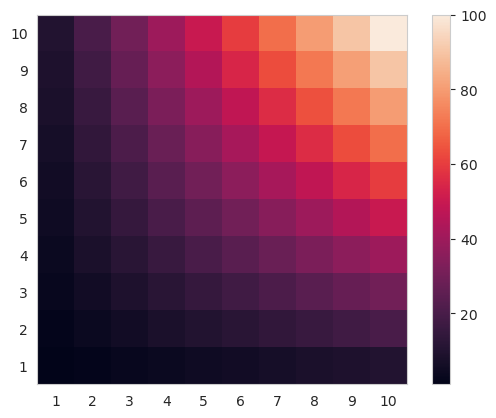

In [6]:
# draw 2d heatmap for multiplication of 1 to 10
x = np.arange(1, 11)
y = np.arange(1, 11)
X, Y = np.meshgrid(x, y)
Z = X * Y

fig, ax = plt.subplots()
im = ax.imshow(Z)
plt.colorbar(im)

# invert y axis
ax.invert_yaxis()
ax.set_xticks(np.arange(len(x)))
ax.set_yticks(np.arange(len(y)))
ax.set_xticklabels(x)
ax.set_yticklabels(y)

# remove grid
ax.grid(False)

plt.show()

In [ ]:
df = read_input(input)
# only keep local global and gini
df = df[['global', 'local', 'gini']]
# df

!mkdir -p out/gini

for global_cache in [1500, 1750, 2000, 2250, 2500][::-1]:
    for local_cache in [500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500][::-1]:
        fig, ax = plt.subplots(figsize=(8, 3), dpi=320)
        for gini in df[(df['global'] == global_cache) & (df['local'] == local_cache)]['gini']:
            gini = eval(gini)
            xs, ys = zip(*gini)
            xs = [x - xs[0] for x in xs]  # normalize to start at 0
            xs = [x / 1e9 for x in xs]  # convert to seconds
            ax.plot(xs, ys, linewidth=.5)

        # zero margin
        ax.margins(x=0.01, y=0)

        # set lim 600
        ax.set_xlim(0, 600)
        ax.set_ylim(0, 1)

        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Gini Coefficient')
        ax.set_title(f'Gini Coefficient Over Time [global={global_cache}, local={local_cache}]')

        # grid every .1 in ys
        ax.yaxis.set_major_locator(plt.MultipleLocator(.1))

        fig.tight_layout()

        write_output(fig, f'out/gini/global-{global_cache}.local-{local_cache}.pdf')

        fig.show()

